
# Deep BSDE validation and direct application to a singular FBSDE

## Black--Scholes--Barenblatt benchmark and two-particle geometry


In [1]:

from __future__ import annotations

import copy
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy.sparse import diags, eye
from scipy.sparse.linalg import spsolve
from torch import Tensor, nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
SEED = 123
FULL_RUN = True

T = 1.0
STEPS = 40 if FULL_RUN else 20
WIDTH = 64 if FULL_RUN else 32
DEPTH = 3 if FULL_RUN else 2
ITERATIONS = 15_000 if FULL_RUN else 1_000
BATCH_SIZE = 1_024 if FULL_RUN else 256
VALIDATION_SIZE = 8_192 if FULL_RUN else 2_048
VALIDATE_EVERY = 200 if FULL_RUN else 50
LEARNING_RATE = 1.0e-3

SIGMA = 1.0
ALPHA = 1.0
X_MIN = 1.0
X_MAX = 4.0

GEOMETRY_TIMES = (0.00, 0.20, 0.40, 0.60, 0.75, 0.90, 0.95, 1.00)
REFERENCE_GRID_SIZE = 61
REFERENCE_PATHS = 2_048 if FULL_RUN else 512
REFERENCE_STEPS = 400 if FULL_RUN else 200
REFERENCE_POINT_BATCH = 32 if FULL_RUN else 16

RESULTS_DIR = Path("benchmark_direct_bsde_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120

print("device", DEVICE)
print("run", "full" if FULL_RUN else "quick")
print("results directory", RESULTS_DIR.resolve())


device cuda
run full
results directory /content/benchmark_direct_bsde_results


In [2]:

def seed_all(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_generator(seed: int) -> torch.Generator:
    try:
        result = torch.Generator(device=DEVICE)
    except TypeError:
        result = torch.Generator()
    result.manual_seed(seed)
    return result


def normal_cdf(value: Tensor) -> Tensor:
    return 0.5 * (1.0 + torch.erf(value / math.sqrt(2.0)))


def tensor_to_numpy(value: Tensor) -> np.ndarray:
    return value.detach().cpu().numpy()


class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        center: tuple[float, ...],
        scale: tuple[float, ...],
    ) -> None:
        super().__init__()
        self.register_buffer("center", torch.tensor(center, dtype=DTYPE).reshape(1, -1))
        self.register_buffer("scale", torch.tensor(scale, dtype=DTYPE).reshape(1, -1))
        layers: list[nn.Module] = []
        current = input_dim
        for _ in range(DEPTH):
            layers.extend([nn.Linear(current, WIDTH), nn.Softplus()])
            current = WIDTH
        layers.append(nn.Linear(current, output_dim))
        self.net = nn.Sequential(*layers)
        self.reset_parameters()

    def reset_parameters(self) -> None:
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x: Tensor) -> Tensor:
        return self.net((x - self.center) / self.scale)


class DeepBSDEModel(nn.Module):
    def __init__(
        self,
        value_input: int,
        value_output: int,
        value_center: tuple[float, ...],
        value_scale: tuple[float, ...],
        w_input: int,
        w_output: int,
        w_center: tuple[float, ...],
        w_scale: tuple[float, ...],
    ) -> None:
        super().__init__()
        self.V = MLP(value_input, value_output, value_center, value_scale)
        self.W = MLP(w_input, w_output, w_center, w_scale)


def time_column(step: int | Tensor | float, batch_size: int) -> Tensor:
    if isinstance(step, (int, np.integer)):
        value = float(step) * T / STEPS
        return torch.full((batch_size, 1), value, device=DEVICE, dtype=DTYPE)
    tensor = torch.as_tensor(step, device=DEVICE, dtype=DTYPE)
    if tensor.ndim == 0:
        tensor = tensor.expand(batch_size)
    return tensor.reshape(batch_size, 1)


def antithetic_batch(
    batch_size: int,
    x_low: float,
    x_high: float,
    rng: torch.Generator,
) -> tuple[Tensor, Tensor]:
    if batch_size % 2 != 0:
        raise ValueError("batch_size must be even for antithetic sampling")
    half = batch_size // 2
    x = x_low + (x_high - x_low) * torch.rand(
        half,
        2,
        generator=rng,
        device=DEVICE,
        dtype=DTYPE,
    )
    normal = torch.randn(
        half,
        STEPS,
        2,
        generator=rng,
        device=DEVICE,
        dtype=DTYPE,
    )
    x = torch.cat((x, x), dim=0)
    normal = torch.cat((normal, -normal), dim=0)
    return x, math.sqrt(T / STEPS) * normal


def fit(model: nn.Module, sampler, loss_function, seed: int) -> pd.DataFrame:
    train_rng = make_generator(seed)
    validation_rng = make_generator(seed + 1)
    validation = sampler(VALIDATION_SIZE, validation_rng)
    optimiser = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_loss = math.inf
    best_state = copy.deepcopy(model.state_dict())
    history: list[tuple[int, float, float]] = []

    for iteration in range(ITERATIONS + 1):
        if iteration:
            model.train()
            batch = sampler(BATCH_SIZE, train_rng)
            optimiser.zero_grad(set_to_none=True)
            loss = loss_function(model, *batch)
            if not torch.isfinite(loss):
                raise FloatingPointError("non-finite training loss")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            optimiser.step()
            train_loss = float(loss.detach().cpu())
        else:
            train_loss = math.nan

        validation_loss = math.nan
        if iteration % VALIDATE_EVERY == 0 or iteration == ITERATIONS:
            model.eval()
            with torch.no_grad():
                validation_loss = float(loss_function(model, *validation).cpu())
            if validation_loss < best_loss:
                best_loss = validation_loss
                best_state = copy.deepcopy(model.state_dict())

        history.append((iteration, train_loss, validation_loss))
        if iteration and iteration % (1000 if FULL_RUN else 250) == 0:
            print(iteration, train_loss, validation_loss)

    model.load_state_dict(best_state)
    model.eval()
    return pd.DataFrame(history, columns=["iteration", "train", "validation"])


def plot_loss_history(
    history: pd.DataFrame,
    title: str,
    *,
    ax: plt.Axes | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.4, 3.8))
    else:
        fig = ax.figure
    train = history.dropna(subset=["train"])
    validation = history.dropna(subset=["validation"])
    ax.semilogy(train.iteration, train.train, linewidth=0.85, label="training")
    ax.semilogy(
        validation.iteration,
        validation.validation,
        marker="o",
        markersize=2.5,
        linewidth=0.85,
        label="validation",
    )
    ax.set_xlabel("iteration")
    ax.set_ylabel("terminal MSE")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()
    return fig, ax


def save_figure(fig: plt.Figure, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


seed_all(SEED)


## 1 Black--Scholes--Barenblatt validation

1000 0.0021812361665070057 0.002263034926727414
2000 0.0005627204664051533 0.00034889430389739573
3000 0.00010539685899857432 0.00011647451901808381
4000 0.00017914504860527813 0.00032513338373973966
5000 8.674475247971714e-05 9.546723595121875e-05
6000 0.00015579909086227417 0.0001964303373824805
7000 0.0001450179552193731 9.759348176885396e-05
8000 0.00024613371351733804 0.0002477686502970755
9000 0.000289440737105906 0.000243831193074584
10000 0.00014125776942819357 0.00016020683688111603
11000 0.00016614168998785317 0.000149601575685665
12000 0.00021051008661743253 0.00010174667841056362
13000 0.00017042878607753664 0.00015755319327581674
14000 0.0001357740256935358 0.00021599471801891923
15000 0.0001417874009348452 0.00015606886881869286


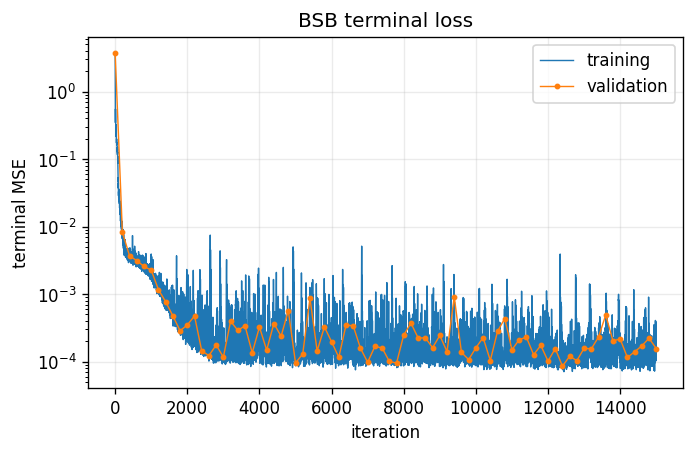

,metric,value
0,NN-PDE field MAE,0.001918
1,NN-exact field MAE,0.001917
2,PDE-exact field MAE,0.000007
3,Z RMSE,0.001305


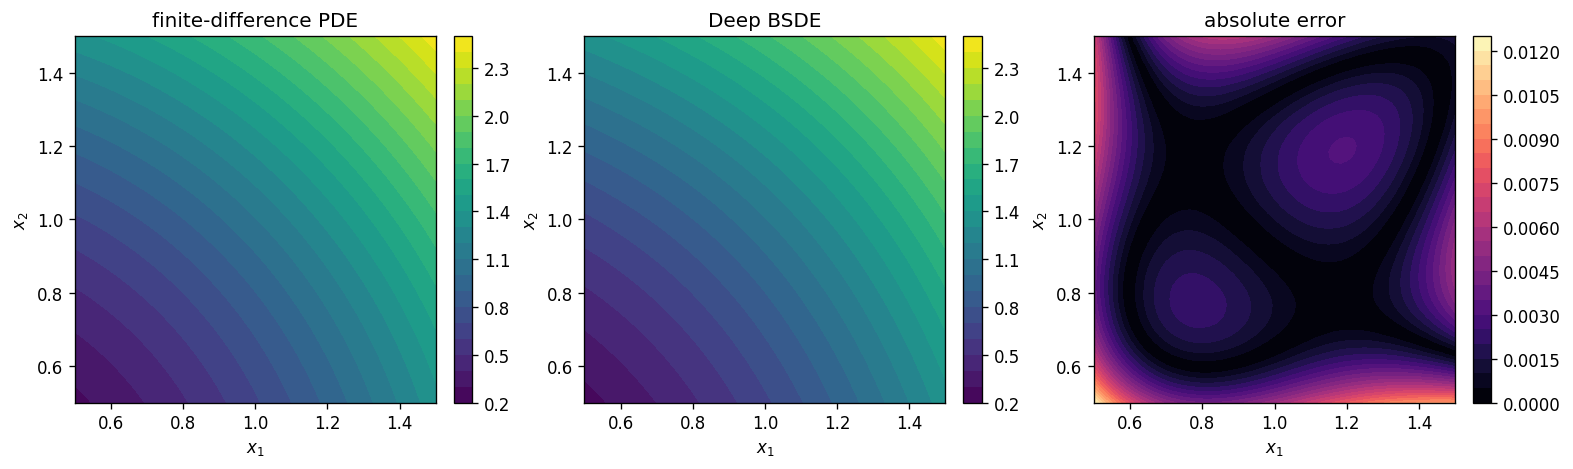

In [3]:

R = 0.05
NU = 0.20


def exact_bsb(t: float, x: Tensor) -> Tensor:
    factor = math.exp((R + NU**2) * (T - t))
    return 0.5 * factor * x.square().sum(dim=1, keepdim=True)


def exact_bsb_z(t: float, x: Tensor) -> Tensor:
    factor = NU * math.exp((R + NU**2) * (T - t))
    return factor * x.square()


def solve_bsb_pde(nx: int = 401, nt: int = 400) -> tuple[np.ndarray, np.ndarray]:
    x_min, x_max = 0.1, 2.5
    x = np.linspace(x_min, x_max, nx)
    tau = np.linspace(0.0, T, nt + 1)
    dx, dt = x[1] - x[0], tau[1] - tau[0]
    interior = x[1:-1]

    lower = 0.5 * NU**2 * interior**2 / dx**2 - 0.5 * R * interior / dx
    main = -NU**2 * interior**2 / dx**2 - R
    upper = 0.5 * NU**2 * interior**2 / dx**2 + 0.5 * R * interior / dx
    operator = diags((lower[1:], main, upper[:-1]), (-1, 0, 1), format="csc")
    identity = eye(nx - 2, format="csc")
    left = identity - 0.5 * dt * operator
    right = identity + 0.5 * dt * operator

    value = 0.5 * x**2
    growth = R + NU**2
    for n in range(nt):
        old_tau, new_tau = tau[n], tau[n + 1]
        old_boundary = 0.5 * np.exp(growth * old_tau) * np.array([x_min**2, x_max**2])
        new_boundary = 0.5 * np.exp(growth * new_tau) * np.array([x_min**2, x_max**2])
        forcing = np.zeros(nx - 2)
        forcing[0] = 0.5 * dt * lower[0] * (old_boundary[0] + new_boundary[0])
        forcing[-1] = 0.5 * dt * upper[-1] * (old_boundary[1] + new_boundary[1])
        interior_value = spsolve(left, right @ value[1:-1] + forcing)
        value = np.r_[new_boundary[0], interior_value, new_boundary[1]]

    return x, value


PDE_X, PDE_W = solve_bsb_pde()


def pde_bsb(x: np.ndarray) -> np.ndarray:
    return np.interp(x[:, 0], PDE_X, PDE_W) + np.interp(x[:, 1], PDE_X, PDE_W)


bsb_model = DeepBSDEModel(
    value_input=2,
    value_output=1,
    value_center=(1.0, 1.0),
    value_scale=(0.5, 0.5),
    w_input=3,
    w_output=2,
    w_center=(0.5, 1.0, 1.0),
    w_scale=(0.5, 0.75, 0.75),
).to(DEVICE)


def sample_bsb(batch_size: int, rng: torch.Generator) -> tuple[Tensor, Tensor]:
    return antithetic_batch(batch_size, 0.5, 1.5, rng)


def bsb_rollout(model: DeepBSDEModel, x0: Tensor, dw: Tensor) -> tuple[Tensor, Tensor]:
    dt = T / STEPS
    x = x0
    y = model.V(x0)
    for k in range(STEPS):
        z = model.W(torch.cat((time_column(k, x.shape[0]), x), dim=1))
        y = y + R * (y - z.sum(1, keepdim=True) / NU) * dt
        y = y + (z * dw[:, k]).sum(1, keepdim=True)
        x = x + NU * x * dw[:, k]
    return y, 0.5 * x.square().sum(1, keepdim=True)


def bsb_loss(model: DeepBSDEModel, x0: Tensor, dw: Tensor) -> Tensor:
    y, target = bsb_rollout(model, x0, dw)
    return (y - target).square().mean()


bsb_history = fit(bsb_model, sample_bsb, bsb_loss, SEED + 100)
plot_loss_history(bsb_history, "BSB terminal loss")
plt.show()
bsb_history.dropna(subset=["validation"]).to_csv(
    RESULTS_DIR / "bsb_history.csv", index=False
)


@torch.no_grad()
def evaluate_bsb() -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    grid = torch.linspace(0.5, 1.5, 61, device=DEVICE)
    x1, x2 = torch.meshgrid(grid, grid, indexing="ij")
    points = torch.stack((x1.ravel(), x2.ravel()), dim=1)
    neural = bsb_model.V(points)[:, 0]
    exact = exact_bsb(0.0, points)[:, 0]
    pde = torch.tensor(pde_bsb(points.detach().cpu().numpy()), device=DEVICE, dtype=DTYPE)
    z = bsb_model.W(torch.cat((time_column(0, points.shape[0]), points), dim=1))

    metrics = pd.DataFrame({
        "metric": [
            "NN-PDE field MAE",
            "NN-exact field MAE",
            "PDE-exact field MAE",
            "Z RMSE",
        ],
        "value": [
            (neural - pde).abs().mean().item(),
            (neural - exact).abs().mean().item(),
            (pde - exact).abs().mean().item(),
            (z - exact_bsb_z(0.0, points)).square().mean().sqrt().item(),
        ],
    })
    fields = {
        "x1": x1.detach().cpu().numpy(),
        "x2": x2.detach().cpu().numpy(),
        "pde": pde.reshape(61, 61).detach().cpu().numpy(),
        "neural": neural.reshape(61, 61).detach().cpu().numpy(),
        "error": (neural - pde).abs().reshape(61, 61).detach().cpu().numpy(),
    }
    return metrics, fields


bsb_metrics, bsb_fields = evaluate_bsb()
display(bsb_metrics)
bsb_metrics.to_csv(RESULTS_DIR / "bsb_metrics.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.8), constrained_layout=True)
for ax, key, title, cmap in zip(
    axes,
    ["pde", "neural", "error"],
    ["finite-difference PDE", "Deep BSDE", "absolute error"],
    ["viridis", "viridis", "magma"],
):
    image = ax.contourf(bsb_fields["x1"], bsb_fields["x2"], bsb_fields[key], 25, cmap=cmap)
    fig.colorbar(image, ax=ax)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)
save_figure(fig, RESULTS_DIR / "bsb_field_comparison_t0.pdf")


## 2 Direct singular application and exact moving-boundary geometry

In [4]:

def exact_singleton_value(t: float | Tensor, x: Tensor) -> Tensor:
    t_tensor = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t_tensor, x_tensor = torch.broadcast_tensors(t_tensor, x)

    remaining = T - t_tensor
    terminal = torch.where(
        x_tensor <= 2.0 * ALPHA,
        torch.full_like(x_tensor, 2.0),
        torch.full_like(x_tensor, 1.0),
    )

    safe_remaining = remaining.clamp_min(torch.finfo(x.dtype).eps)
    argument = torch.minimum(
        (2.0 * ALPHA - x_tensor) / (SIGMA * torch.sqrt(safe_remaining)),
        torch.zeros_like(x_tensor),
    )
    preterminal = 1.0 + 2.0 * normal_cdf(argument)
    return torch.where(remaining <= 1.0e-12, terminal, preterminal)


def exact_boundary_value(t: float | Tensor, survivor: Tensor) -> Tensor:
    return ALPHA * exact_singleton_value(t, survivor)


def exact_terminal_continuation_mask(points: Tensor) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values
    return (smaller > ALPHA) & (larger > 2.0 * ALPHA)


def exact_continuation_mask(t: float | Tensor, points: Tensor) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values
    t_tensor = torch.as_tensor(t, device=points.device, dtype=points.dtype)
    if t_tensor.ndim == 0 and abs(float(t_tensor.item()) - T) <= 1.0e-12:
        return exact_terminal_continuation_mask(points)
    if t_tensor.ndim == 0:
        t_tensor = t_tensor.expand(points.shape[0])
    return smaller > exact_boundary_value(t_tensor, larger)


def exact_boundary_curves(t: float) -> list[tuple[np.ndarray, np.ndarray]]:
    if abs(t - T) <= 1.0e-12:
        low = np.linspace(X_MIN, 2.0 * ALPHA, 500)
        high = np.linspace(2.0 * ALPHA, X_MAX, 500)
        return [
            (np.full_like(low, 2.0 * ALPHA), low),
            (low, np.full_like(low, 2.0 * ALPHA)),
            (np.full_like(high, ALPHA), high),
            (high, np.full_like(high, ALPHA)),
        ]

    survivor = torch.linspace(
        max(X_MIN, 2.0 * ALPHA),
        X_MAX,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )
    boundary = exact_boundary_value(t, survivor)
    feasible = boundary <= survivor + 10.0 * torch.finfo(DTYPE).eps
    survivor = survivor[feasible]
    boundary = boundary[feasible]
    return [
        (tensor_to_numpy(boundary), tensor_to_numpy(survivor)),
        (tensor_to_numpy(survivor), tensor_to_numpy(boundary)),
    ]


def plot_exact_boundary(ax: plt.Axes, time_value: float, label: str | None = None) -> None:
    for curve_index, (x_curve, y_curve) in enumerate(exact_boundary_curves(time_value)):
        ax.plot(
            x_curve,
            y_curve,
            color="red",
            linestyle=(0, (10, 5)),
            linewidth=1.25,
            alpha=0.95,
            label=label if curve_index == 0 else None,
            zorder=6,
        )


@torch.no_grad()
def reference_payoff_chunk(start_time: float, points: Tensor, increments: Tensor) -> Tensor:
    n_points = points.shape[0]
    n_paths = increments.shape[0]
    n_steps = increments.shape[1]
    dt = (T - start_time) / n_steps

    x = points[:, None, :].expand(n_points, n_paths, 2).clone()
    active = torch.ones(n_points, n_paths, device=DEVICE, dtype=torch.bool)
    payoff = torch.zeros(n_points, n_paths, device=DEVICE, dtype=DTYPE)

    for k in range(n_steps + 1):
        current_time = start_time + k * dt
        smaller = x.min(dim=2).values
        larger = x.max(dim=2).values
        threshold = exact_boundary_value(current_time, larger)
        new_exit = active & (smaller <= threshold)

        if bool(new_exit.any()):
            payoff[new_exit] = exact_singleton_value(current_time, larger[new_exit])
            active[new_exit] = False

        if k < n_steps:
            x = x + increments[:, k][None, :, :]

    return payoff


@torch.no_grad()
def compute_reference_surface(start_time: float) -> dict[str, Tensor]:
    axis = torch.linspace(X_MIN, X_MAX, REFERENCE_GRID_SIZE, device=DEVICE, dtype=DTYPE)
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)

    inside = exact_continuation_mask(start_time, points)
    field = exact_singleton_value(start_time, points.max(dim=1).values)
    standard_error = torch.zeros_like(field)

    if abs(start_time - T) <= 1.0e-12:
        field[inside] = 0.0
        return {
            "axis": axis.cpu(),
            "points": points.cpu(),
            "inside": inside.cpu(),
            "field": field.cpu(),
            "standard_error": standard_error.cpu(),
        }

    inside_points = points[inside]
    if REFERENCE_PATHS % 2 != 0:
        raise ValueError("REFERENCE_PATHS must be even")

    half_paths = REFERENCE_PATHS // 2
    rng = make_generator(SEED + 10_000 + int(1_000 * start_time))
    half_normals = torch.randn(
        half_paths,
        REFERENCE_STEPS,
        2,
        generator=rng,
        device=DEVICE,
        dtype=DTYPE,
    )
    normals = torch.cat((half_normals, -half_normals), dim=0)
    dt = (T - start_time) / REFERENCE_STEPS
    increments = SIGMA * math.sqrt(dt) * normals

    estimates: list[Tensor] = []
    errors: list[Tensor] = []
    for start in range(0, inside_points.shape[0], REFERENCE_POINT_BATCH):
        chunk = inside_points[start:start + REFERENCE_POINT_BATCH]
        samples = reference_payoff_chunk(start_time, chunk, increments)
        pair_means = 0.5 * (samples[:, :half_paths] + samples[:, half_paths:])
        estimates.append(pair_means.mean(dim=1))
        errors.append(pair_means.std(dim=1, unbiased=True) / math.sqrt(half_paths))

    if estimates:
        field[inside] = torch.cat(estimates)
        standard_error[inside] = torch.cat(errors)

    return {
        "axis": axis.cpu(),
        "points": points.cpu(),
        "inside": inside.cpu(),
        "field": field.cpu(),
        "standard_error": standard_error.cpu(),
    }


reference_surfaces: dict[float, dict[str, Tensor]] = {}
for t_value in GEOMETRY_TIMES:
    print(f"Computing independent reference at t={t_value:.2f}")
    reference_surfaces[float(t_value)] = compute_reference_surface(float(t_value))


Computing independent reference at t=0.00
Computing independent reference at t=0.20
Computing independent reference at t=0.40
Computing independent reference at t=0.60
Computing independent reference at t=0.75
Computing independent reference at t=0.90
Computing independent reference at t=0.95
Computing independent reference at t=1.00


1000 0.025683369487524033 0.0265043918043375
2000 0.014591422863304615 0.014901777729392052
3000 0.01170121505856514 0.012398649007081985
4000 0.010083694010972977 0.00966307707130909
5000 0.007943697273731232 0.008543058298528194
6000 0.007077117916196585 0.008091716095805168
7000 0.006368292961269617 0.007621625438332558
8000 0.006772100459784269 0.007357549853622913
9000 0.006077473983168602 0.007061490789055824
10000 0.0072052981704473495 0.006951136514544487
11000 0.006928616669028997 0.00680924765765667
12000 0.00748883280903101 0.006684045772999525
13000 0.0068472689017653465 0.006339445244520903
14000 0.005902037024497986 0.006564644165337086
15000 0.006330971606075764 0.006276526488363743


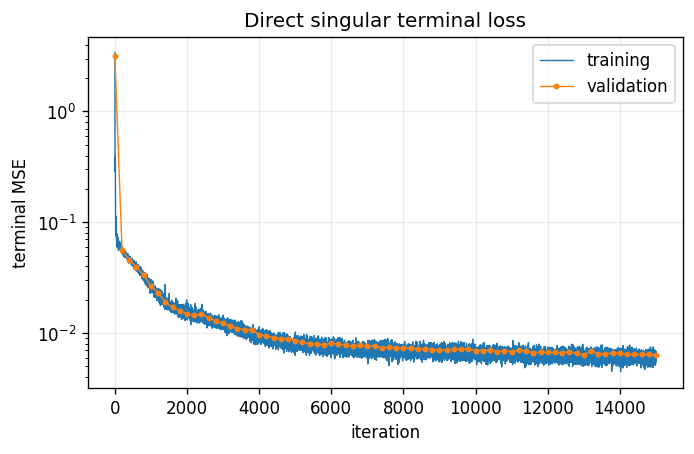

In [5]:

singular_model = DeepBSDEModel(
    value_input=4,
    value_output=2,
    value_center=(2.5, 2.5, 0.5, 0.5),
    value_scale=(1.5, 1.5, 0.5, 0.5),
    w_input=5,
    w_output=4,
    w_center=(0.5, 2.5, 2.5, 0.5, 0.5),
    w_scale=(0.5, 1.5, 1.5, 0.5, 0.5),
).to(DEVICE)


def sample_singular(batch_size: int, rng: torch.Generator) -> tuple[Tensor, Tensor]:
    return antithetic_batch(batch_size, X_MIN, X_MAX, rng)


def singular_rollout(
    model: DeepBSDEModel,
    x0: Tensor,
    dw: Tensor,
    return_history: bool = False,
) -> dict[str, Tensor]:
    x = x0
    alive = torch.ones_like(x0, dtype=torch.bool)
    killed = torch.zeros_like(alive)
    y = model.V(torch.cat((x0, alive.to(DTYPE)), dim=1))
    history = []

    for k in range(STEPS):
        with torch.no_grad():
            hit = alive & (x <= ALPHA * y.detach().sum(1, keepdim=True))
            killed = killed | hit
            alive = alive & (~hit)
        if return_history:
            history.append(y)
        features = torch.cat((time_column(k, x.shape[0]), x, alive.to(DTYPE)), dim=1)
        z = model.W(features).reshape(-1, 2, 2)
        y = y + torch.einsum("bij,bj->bi", z, dw[:, k])
        x = x + SIGMA * dw[:, k]

    with torch.no_grad():
        hit = alive & (x <= ALPHA * y.detach().sum(1, keepdim=True))
        killed = killed | hit

    if return_history:
        history.append(y)

    return {
        "y": y,
        "target": killed.to(DTYPE),
        "history": torch.stack(history, dim=1) if return_history else y[:, None],
    }


def singular_loss(model: DeepBSDEModel, x0: Tensor, dw: Tensor) -> Tensor:
    output = singular_rollout(model, x0, dw)
    return (output["y"] - output["target"]).square().mean()


singular_history = fit(singular_model, sample_singular, singular_loss, SEED + 300)
plot_loss_history(singular_history, "Direct singular terminal loss")
plt.show()
singular_history.dropna(subset=["validation"]).to_csv(
    RESULTS_DIR / "direct_singular_history.csv", index=False
)


,metric,value
0,terminal RMSE,0.076536
1,indicator mean,0.333191
2,range violation rate,0.319967
3,aggregate minimum,0.009426
4,aggregate maximum,2.065189


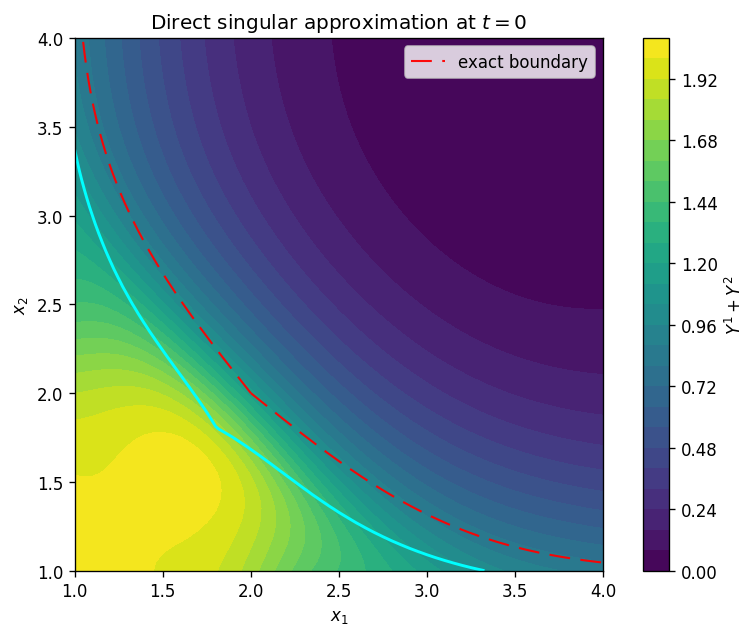

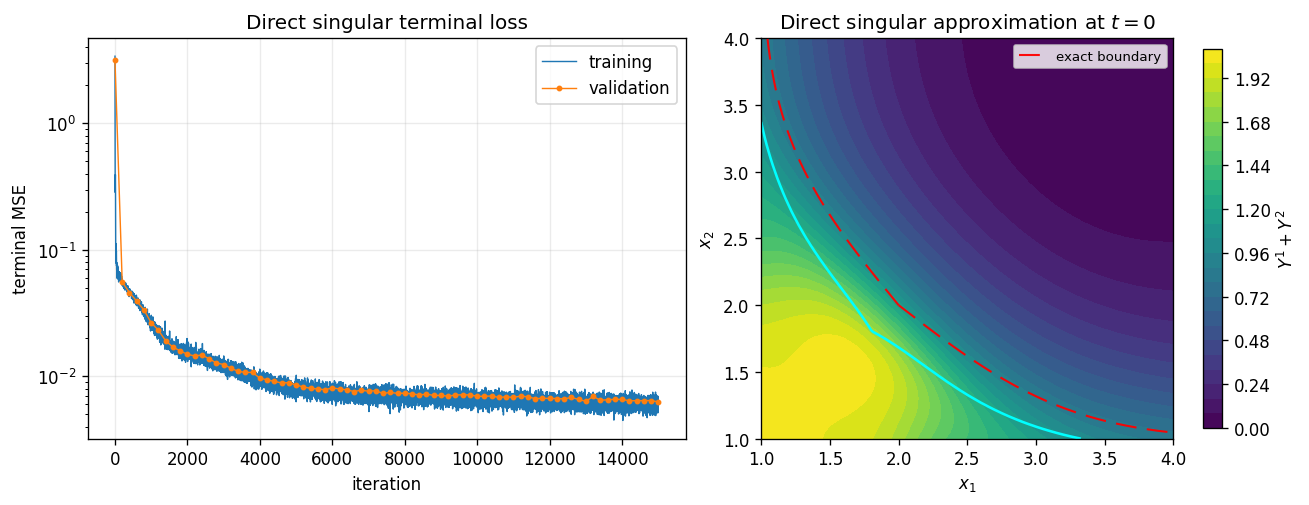

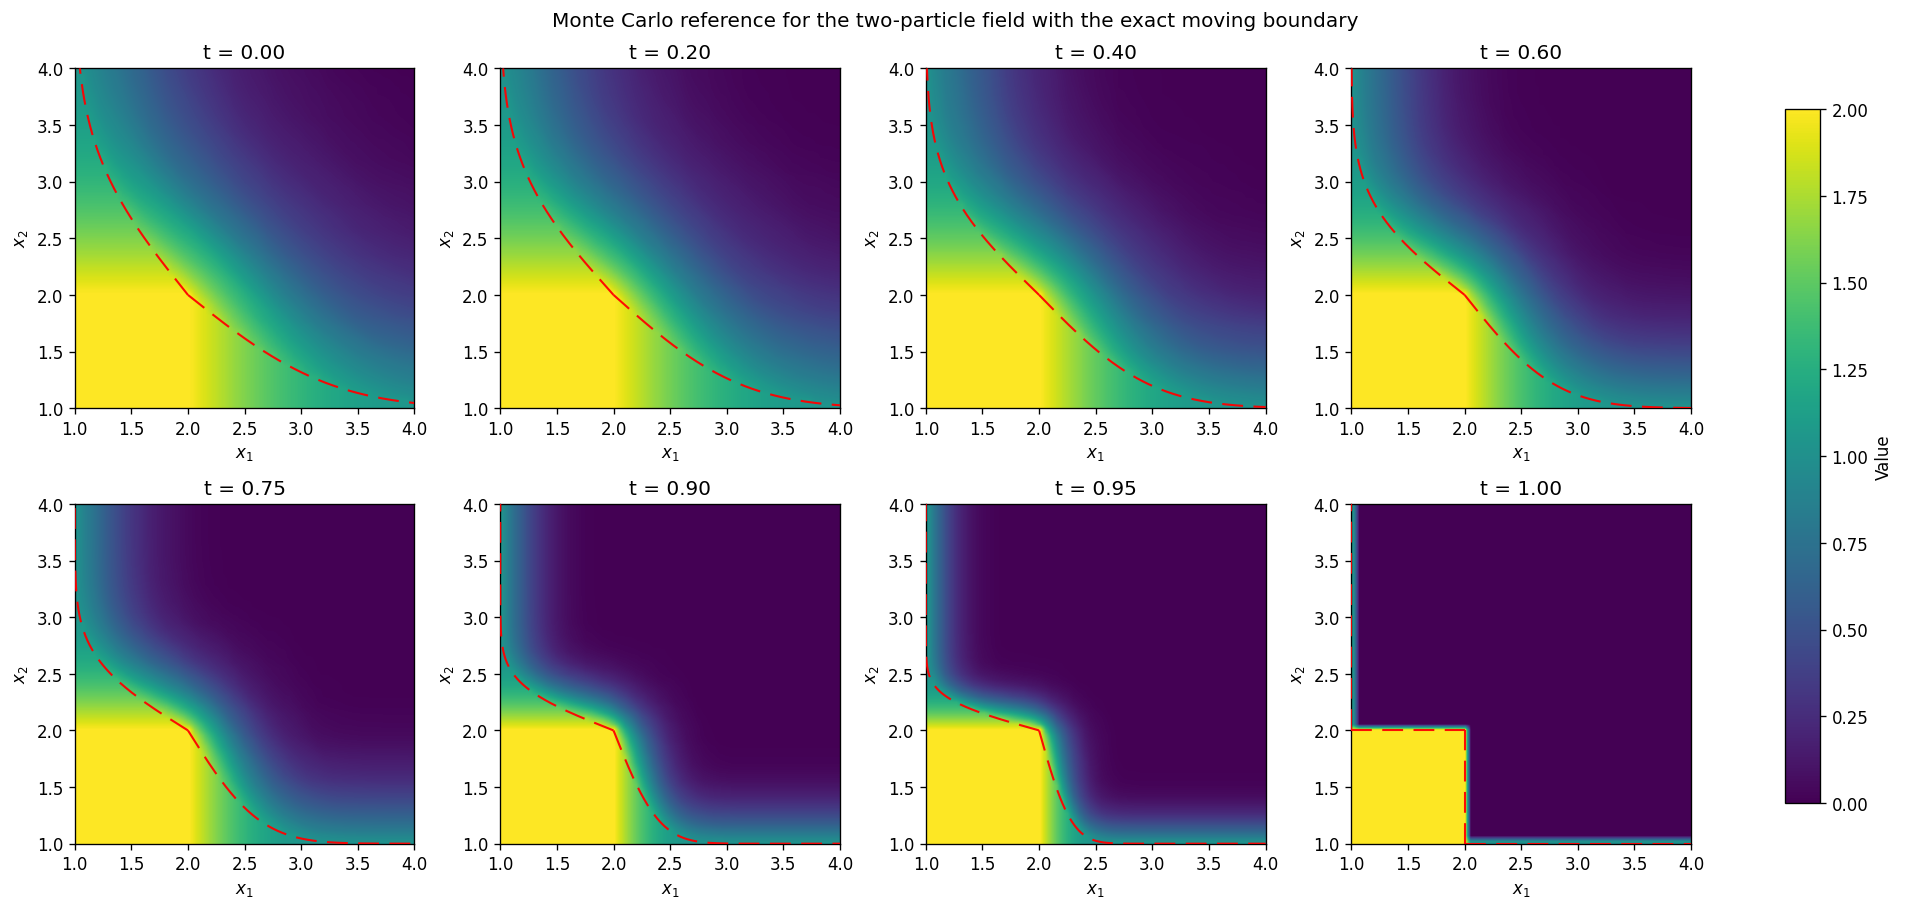

,time,Mean Monte Carlo SE,Maximum Monte Carlo SE
0,0.00,0.009544,0.013396
1,0.20,0.008908,0.013642
2,0.40,0.008089,0.014167
3,0.60,0.006883,0.014425
4,0.75,0.005654,0.015025
5,0.90,0.003772,0.015676
6,0.95,0.002866,0.015938
7,1.00,0.000000,0.000000


In [6]:

@torch.no_grad()
def evaluate_singular() -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    rng = make_generator(SEED + 400)
    x0, dw = sample_singular(8_192 if FULL_RUN else 2_048, rng)
    output = singular_rollout(singular_model, x0, dw, True)
    residual = output["y"] - output["target"]
    path_values = output["history"].reshape(-1)

    grid = torch.linspace(X_MIN, X_MAX, 61, device=DEVICE)
    x1, x2 = torch.meshgrid(grid, grid, indexing="ij")
    points = torch.stack((x1.ravel(), x2.ravel()), dim=1)
    alive = torch.ones_like(points)
    components = singular_model.V(torch.cat((points, alive), dim=1))
    aggregate = components.sum(1)
    boundary = points.min(1).values - ALPHA * aggregate

    metrics = pd.DataFrame({
        "metric": [
            "terminal RMSE",
            "indicator mean",
            "range violation rate",
            "aggregate minimum",
            "aggregate maximum",
        ],
        "value": [
            residual.square().mean().sqrt().item(),
            output["target"].mean().item(),
            ((path_values < 0) | (path_values > 1)).float().mean().item(),
            aggregate.min().item(),
            aggregate.max().item(),
        ],
    })
    fields = {
        "x1": x1.detach().cpu().numpy(),
        "x2": x2.detach().cpu().numpy(),
        "aggregate": aggregate.reshape(61, 61).detach().cpu().numpy(),
        "boundary": boundary.reshape(61, 61).detach().cpu().numpy(),
    }
    return metrics, fields


singular_metrics, singular_fields = evaluate_singular()
display(singular_metrics)
singular_metrics.to_csv(RESULTS_DIR / "direct_singular_metrics.csv", index=False)

# Direct singular heatmap at time zero.
fig, ax = plt.subplots(figsize=(6.2, 5.2), constrained_layout=True)
surface = ax.contourf(
    singular_fields["x1"],
    singular_fields["x2"],
    singular_fields["aggregate"],
    25,
    cmap="viridis",
)
fig.colorbar(surface, ax=ax, label="$Y^1+Y^2$")
ax.contour(
    singular_fields["x1"],
    singular_fields["x2"],
    singular_fields["boundary"],
    levels=[0.0],
    colors="cyan",
    linewidths=1.75,
)
plot_exact_boundary(ax, 0.0, label="exact boundary")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Direct singular approximation at $t=0$")
ax.legend(loc="upper right")
save_figure(fig, RESULTS_DIR / "direct_singular_heatmap_t0.pdf")

# Dissertation-ready two-panel figure.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.8, 4.1),
    gridspec_kw={"width_ratios": [1.45, 1.0]},
    constrained_layout=True,
)
plot_loss_history(singular_history, "Direct singular terminal loss", ax=axes[0])
surface = axes[1].contourf(
    singular_fields["x1"],
    singular_fields["x2"],
    singular_fields["aggregate"],
    25,
    cmap="viridis",
)
axes[1].contour(
    singular_fields["x1"],
    singular_fields["x2"],
    singular_fields["boundary"],
    levels=[0.0],
    colors="cyan",
    linewidths=1.55,
)
plot_exact_boundary(axes[1], 0.0, label="exact boundary")
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")
axes[1].set_title("Direct singular approximation at $t=0$")
axes[1].legend(loc="upper right", fontsize=8)
fig.colorbar(surface, ax=axes[1], fraction=0.046, pad=0.04, label="$Y^1+Y^2$")
save_figure(fig, RESULTS_DIR / "direct_singular_loss_and_heatmap.pdf")

# Exact moving-boundary geometry across time.
fig, axes = plt.subplots(2, 4, figsize=(15.8, 7.5), constrained_layout=True)
image = None
for ax, t_value in zip(axes.flat, GEOMETRY_TIMES):
    reference = reference_surfaces[float(t_value)]
    axis_np = reference["axis"].numpy()
    field = reference["field"].numpy().reshape(REFERENCE_GRID_SIZE, REFERENCE_GRID_SIZE)

    image = ax.imshow(
        field.T,
        origin="lower",
        extent=[axis_np[0], axis_np[-1], axis_np[0], axis_np[-1]],
        aspect="equal",
        interpolation="bilinear",
        cmap="viridis",
        vmin=0.0,
        vmax=2.0,
    )
    plot_exact_boundary(ax, float(t_value))
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(X_MIN, X_MAX)
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(f"t = {t_value:.2f}")

if image is None:
    raise RuntimeError("reference figure was not created")

colorbar = fig.colorbar(image, ax=axes, shrink=0.86)
colorbar.set_label("Value")
fig.suptitle("Monte Carlo reference for the two-particle field with the exact moving boundary")
save_figure(fig, RESULTS_DIR / "reference_field_eight_times.pdf")

reference_uncertainty_rows = []
for t_value in GEOMETRY_TIMES:
    reference = reference_surfaces[float(t_value)]
    inside = reference["inside"]
    standard_error = reference["standard_error"]
    inside_se = standard_error[inside]
    reference_uncertainty_rows.append({
        "time": float(t_value),
        "Mean Monte Carlo SE": float(inside_se.mean()) if inside_se.numel() else 0.0,
        "Maximum Monte Carlo SE": float(inside_se.max()) if inside_se.numel() else 0.0,
    })

reference_uncertainty = pd.DataFrame(reference_uncertainty_rows)
reference_uncertainty.to_csv(
    RESULTS_DIR / "reference_monte_carlo_uncertainty.csv", index=False
)
display(reference_uncertainty.round(6))



The benchmark validates the basic Deep BSDE implementation against both the analytical Black--Scholes--Barenblatt solution and an independent finite-difference computation. The direct singular experiment is intentionally naive. Its terminal loss is therefore only an internal optimisation diagnostic and should be interpreted together with the time-zero heatmap, the range checks, and the exact moving-boundary reference geometry.
